# Comparación práctica entre TF-IDF y embeddings

Este notebook retoma la evolución natural del proyecto. El primer enfoque fue `TF-IDF + LogisticRegression`, que funcionaba bien cuando el texto era corto, directo y parecido a lo visto en entrenamiento. Sin embargo, al pasar de clasificar posts a construir un sistema de recomendación, aparecieron limitaciones claras: el modelo dependía mucho de palabras concretas y le costaba más interpretar frases mixtas o ambiguas.

Por eso se compara aquí con el enfoque basado en embeddings. La comparación se apoya en el modelo multilingüe `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` persistido en el notebook 02, porque es el que mejor encaja con un corpus y unas consultas formuladas principalmente en español.


## 1. Preparación de modelos

Se cargan tres elementos muy simples:

- el dataset `data/posts.csv`,
- el pipeline TF-IDF ya entrenado,
- y el sistema de embeddings multilingüe con los posts vectorizados.

No se vuelve a entrenar nada en este notebook. Solo se reutilizan los artefactos generados en los pasos anteriores del proyecto para comparar el baseline léxico con el espacio semántico multilingüe adoptado como enfoque final.


In [22]:
import re
import unicodedata
from pathlib import Path
from textwrap import shorten

import joblib
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.metrics.pairwise import cosine_similarity

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError(
        "Falta instalar sentence-transformers. Ejecuta: %pip install -q sentence-transformers"
    ) from exc

DATA_PATH = Path("data/posts.csv")
TFIDF_PIPELINE_PATH = Path("pipeline_textual.pkl")
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_MODEL_DIR = Path("models/modelo_embeddings")
EMBEDDINGS_ARTIFACT_PATH = Path("artifacts/embeddings_posts.joblib")
GRAFICA_COMPARACION_PATH = Path("artifacts/comparacion_modelos_embeddings.png")
GRAFICA_DISTRIBUCION_PATH = Path("artifacts/distribucion_categorias_posts.png")
DETALLE_COMPARACION_DIR = Path("artifacts/comparacion_detalle")

CONSULTAS = [
    "jugando al FIFA escuchando música",
    "viaje en coche por la costa",
    "vacaciones con música y playa",
    "nueva canción de Anuel",
    "cocinando mientras veo fútbol",
]

CONSULTAS_GRAFICA = CONSULTAS + [
    "playlist para conducir de noche hacia la playa",
    "sartén en marcha y el partido de fondo",
    "escapada improvisada con ventanilla bajada y canciones de verano",
    "tarde de consola con cascos y temazos",
    "maleta, costa y radio a todo volumen",
]

CATEGORIAS_ESPERADAS = {
    "jugando al FIFA escuchando música": {"videojuegos", "musica"},
    "viaje en coche por la costa": {"viajes", "coches", "playa"},
    "vacaciones con música y playa": {"playa", "viajes", "musica"},
    "nueva canción de Anuel": {"musica"},
    "cocinando mientras veo fútbol": {"cocina", "deporte"},
    "playlist para conducir de noche hacia la playa": {"musica", "coches", "viajes", "playa"},
    "sartén en marcha y el partido de fondo": {"cocina", "deporte"},
    "escapada improvisada con ventanilla bajada y canciones de verano": {"viajes", "coches", "musica"},
    "tarde de consola con cascos y temazos": {"videojuegos", "musica"},
    "maleta, costa y radio a todo volumen": {"viajes", "playa", "musica"},
}

COMENTARIOS = {
    "jugando al FIFA escuchando música": (
        "TF-IDF se queda con la parte más visible del texto y lo resume como videojuegos. "
        "Embeddings también acerca la consulta a videojuegos, pero además recupera posts donde juego y música aparecen mezclados, "
        "lo que resulta más natural para recomendar contenido parecido."
    ),
    "viaje en coche por la costa": (
        "Aquí la frase mezcla viaje, coche y costa. TF-IDF termina eligiendo una sola categoría, mientras que embeddings devuelve ejemplos "
        "repartidos entre viajes, coches y playa. Esa mezcla encaja mejor con la idea de una recomendación real."
    ),
    "vacaciones con música y playa": (
        "TF-IDF ofrece una salida simple y limpia: playa. Embeddings aporta una lista más variada y cercana al significado completo del texto, "
        "aunque también deja ver algo de ruido en el ranking, algo normal cuando varias señales aparecen juntas."
    ),
    "nueva canción de Anuel": (
        "Este caso es bastante claro y ambos enfoques responden bien. Sirve para recordar que TF-IDF sigue siendo útil cuando el texto "
        "es directo y usa palabras muy reconocibles dentro del dominio."
    ),
    "cocinando mientras veo fútbol": (
        "Este es el ejemplo más ilustrativo. TF-IDF se descoloca y predice una categoría poco intuitiva, mientras que embeddings recupera "
        "posts entre cocina y deporte. La lectura práctica es que embeddings maneja mejor los textos ambiguos o mezclados."
    ),
}

pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8765.20it/s]


Dataset utilizado: data\posts.csv
Número de registros: 11000
Categorías disponibles: 8
Pipeline TF-IDF: pipeline_textual.pkl
Modelo de embeddings activo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Directorio local activo: models\modelo_embeddings
Posts disponibles para recomendar: 10873


,descripcion,hashtags,categoria
0,plan improvisado: despues del gym cayo MasterChef porque el cuerpo lo pidio random pero necesario,#cocina #partido,deporte
1,mini update: vuelo temprano con cafe dudoso sin filtros y con prisa 🎸,#gymbro #escapada #top,viajes
2,vuelo temprano con cafe dudoso en Londres con camara,#Travel,viajes
3,"vibe de hoy: baño rapido antes de comer, que locura jajaja",#Random#Verano,playa
4,"vibe de hoy: brisa salada y cero prisa, ns q decir jaja",#sol,playa


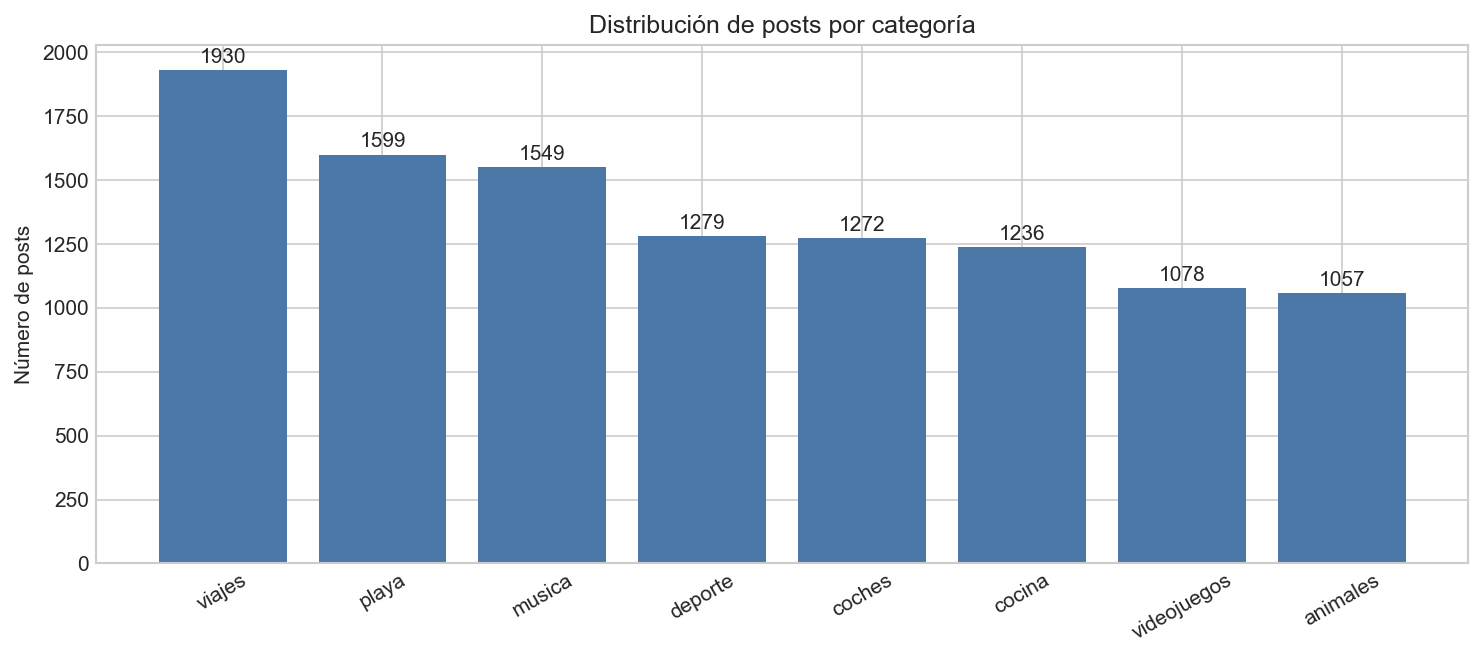

In [23]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset en {DATA_PATH}")
if not TFIDF_PIPELINE_PATH.exists():
    raise FileNotFoundError(f"No se encontró el pipeline TF-IDF en {TFIDF_PIPELINE_PATH}")
if not EMBEDDINGS_ARTIFACT_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el artefacto de embeddings en {EMBEDDINGS_ARTIFACT_PATH}. Ejecuta antes el notebook 02."
    )
if not EMBEDDING_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró el modelo de embeddings en {EMBEDDING_MODEL_DIR}. Ejecuta antes el notebook 02."
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8")
tfidf_pipeline = joblib.load(TFIDF_PIPELINE_PATH)
embedding_artifact = joblib.load(EMBEDDINGS_ARTIFACT_PATH)

embedding_model_name_artifact = embedding_artifact.get("embedding_model_name", EMBEDDING_MODEL_NAME)
if embedding_model_name_artifact != EMBEDDING_MODEL_NAME:
    raise ValueError(
        "El artefacto de embeddings no fue generado con el modelo multilingüe esperado. "
        f"Se encontró {embedding_model_name_artifact} y se esperaba {EMBEDDING_MODEL_NAME}. "
        "Reejecuta el notebook 02 para regenerarlo."
    )

embedding_model_dir = Path(embedding_artifact.get("embedding_model_dir", EMBEDDING_MODEL_DIR))
if not embedding_model_dir.exists():
    embedding_model_dir = EMBEDDING_MODEL_DIR
if not embedding_model_dir.exists():
    raise FileNotFoundError(
        f"No se encontró el modelo multilingüe en {embedding_model_dir}. Ejecuta antes el notebook 02."
    )

embedding_model = SentenceTransformer(str(embedding_model_dir), local_files_only=True)

posts_embeddings = embedding_artifact["posts"].copy().reset_index(drop=True)
matriz_embeddings = embedding_artifact["embeddings"]

print(f"Dataset utilizado: {DATA_PATH}")
print(f"Número de registros: {len(df)}")
print(f"Categorías disponibles: {df['categoria'].nunique()}")
print(f"Pipeline TF-IDF: {TFIDF_PIPELINE_PATH}")
print(f"Modelo de embeddings activo: {EMBEDDING_MODEL_NAME}")
print(f"Directorio local activo: {embedding_model_dir}")
print(f"Posts disponibles para recomendar: {len(posts_embeddings)}")

display(df[["descripcion", "hashtags", "categoria"]].head(5))

conteo_categorias = df["categoria"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(conteo_categorias.index, conteo_categorias.values, color="#4C78A8")
ax.set_title("Distribución de posts por categoría")
ax.set_ylabel("Número de posts")
ax.tick_params(axis="x", rotation=30)

for i, valor in enumerate(conteo_categorias.values):
    ax.text(i, valor + max(conteo_categorias.values) * 0.015, str(valor), ha="center")

plt.tight_layout()
GRAFICA_DISTRIBUCION_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(GRAFICA_DISTRIBUCION_PATH, dpi=150, bbox_inches="tight")
display(Image(filename=str(GRAFICA_DISTRIBUCION_PATH)))
plt.close(fig)


## 2. Comparación mediante ejemplos reales

Esta es la parte central del notebook. Para cada consulta se muestran cuatro piezas complementarias:

- la predicción principal de `TF-IDF`,
- sus tres categorías más probables y la incertidumbre con la que decide,
- el top-5 recuperado por embeddings multilingües con sus similitudes,
- y una lectura breve de qué está ocurriendo en ese ejemplo.

La idea no es medir por medir, sino observar el comportamiento real de ambos enfoques. En textos directos, `TF-IDF` suele verse claro y contundente. En frases ambiguas, la comparación se vuelve más interesante: el espacio semántico multilingüe tiende a repartir mejor la señal y a devolver recomendaciones más naturales para un corpus social en español.


In [24]:
def preprocesar_tfidf(texto: str) -> str:
    texto = str(texto).lower().replace("#", " ")
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def preparar_texto_embedding(texto: str) -> str:
    texto = str(texto).replace("#", " ")
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def slugificar_texto(texto: str) -> str:
    normalizado = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-z0-9]+", "_", normalizado.lower()).strip("_")


def predecir_tfidf(consulta: str, top_n: int = 3) -> dict:
    consulta_limpia = preprocesar_tfidf(consulta)
    probabilidades = tfidf_pipeline.predict_proba([consulta_limpia])[0]
    clases = tfidf_pipeline.named_steps["clasificador"].classes_
    indices_ordenados = probabilidades.argsort()[::-1][:top_n]
    top_categorias = pd.DataFrame(
        {
            "categoria": [clases[i] for i in indices_ordenados],
            "score": [float(probabilidades[i]) for i in indices_ordenados],
        }
    )
    entropia = float(
        -(probabilidades * np.log(probabilidades + 1e-12)).sum() / np.log(len(probabilidades))
    )
    margen_top2 = float(top_categorias.iloc[0]["score"] - top_categorias.iloc[1]["score"])
    return {
        "consulta": consulta,
        "texto_analizado": consulta_limpia,
        "prediccion": top_categorias.iloc[0]["categoria"],
        "confianza_top1": float(top_categorias.iloc[0]["score"]),
        "incertidumbre": entropia,
        "margen_top2": margen_top2,
        "top_categorias": top_categorias,
    }


def recomendar_embeddings(consulta: str, top_k: int = 5) -> pd.DataFrame:
    texto = preparar_texto_embedding(consulta)
    embedding_consulta = embedding_model.encode(
        [texto],
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    scores = cosine_similarity(embedding_consulta, matriz_embeddings).ravel()
    ranking = posts_embeddings.copy()
    ranking["score"] = scores
    ranking = ranking.sort_values("score", ascending=False).head(top_k).copy().reset_index(drop=True)
    ranking.insert(0, "posicion", np.arange(1, len(ranking) + 1))
    columnas = [
        columna
        for columna in [
            "posicion",
            "score",
            "categoria",
            "categoria_secundaria",
            "es_ambiguo",
            "descripcion",
            "hashtags",
        ]
        if columna in ranking.columns
    ]
    return ranking[columnas]


def resumir_embeddings(ranking_embeddings: pd.DataFrame, esperado: set[str]) -> dict:
    categorias = ranking_embeddings["categoria"].astype(str).tolist()
    categorias_encontradas = len(set(categorias) & esperado)
    return {
        "similitud_top1": float(ranking_embeddings.iloc[0]["score"]),
        "similitud_media_top5": float(ranking_embeddings["score"].mean()),
        "diversidad_top5": float(ranking_embeddings["categoria"].nunique() / len(ranking_embeddings)),
        "cobertura_esperada": float(categorias_encontradas / len(esperado)),
        "proporcion_relevantes": float(ranking_embeddings["categoria"].isin(esperado).mean()),
        "categorias_recuperadas": categorias,
    }


def preparar_tabla_embeddings(ranking_embeddings: pd.DataFrame, esperado: set[str]) -> pd.DataFrame:
    tabla = ranking_embeddings.copy()
    tabla["score"] = tabla["score"].round(4)
    tabla["relevancia"] = np.where(tabla["categoria"].isin(esperado), "alineado", "periférico")
    if "descripcion" in tabla.columns:
        tabla["descripcion_corta"] = tabla["descripcion"].fillna("").map(
            lambda texto: shorten(str(texto), width=55, placeholder="...")
        )
    columnas = [
        columna
        for columna in ["posicion", "categoria", "score", "relevancia", "descripcion_corta", "hashtags"]
        if columna in tabla.columns
    ]
    return tabla[columnas].rename(
        columns={
            "score": "similitud_coseno",
            "descripcion_corta": "descripcion",
        }
    )


def graficar_detalle_consulta(
    consulta: str,
    esperado: set[str],
    resultado_tfidf: dict,
    ranking_embeddings: pd.DataFrame,
    resumen_embeddings: dict,
) -> None:
    tfidf_plot = resultado_tfidf["top_categorias"].sort_values("score", ascending=True)
    ranking_plot = ranking_embeddings.copy().sort_values("score", ascending=True)
    etiquetas_embeddings = [
        f"{fila.posicion}. {fila.categoria}"
        for fila in ranking_plot[["posicion", "categoria"]].itertuples(index=False)
    ]
    colores_embeddings = [
        "#7FC8A9" if categoria in esperado else "#D8DEE9"
        for categoria in ranking_plot["categoria"]
    ]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.25]})

    axes[0].barh(tfidf_plot["categoria"], tfidf_plot["score"], color="#86BBD8")
    axes[0].set_xlim(0, max(0.55, tfidf_plot["score"].max() + 0.12))
    axes[0].set_title("TF-IDF: top-3 categorías")
    axes[0].set_xlabel(
        f"Confianza top-1: {resultado_tfidf['confianza_top1']:.2f} | "
        f"margen top-2: {resultado_tfidf['margen_top2']:.2f}"
    )
    for categoria, score in zip(tfidf_plot["categoria"], tfidf_plot["score"]):
        axes[0].text(score + 0.01, categoria, f"{score:.2f}", va="center", fontsize=9)

    axes[1].barh(etiquetas_embeddings, ranking_plot["score"], color=colores_embeddings)
    axes[1].axvline(
        resumen_embeddings["similitud_media_top5"],
        color="#5B6570",
        linestyle="--",
        linewidth=1.2,
    )
    axes[1].set_xlim(0, max(0.55, ranking_plot["score"].max() + 0.08))
    axes[1].set_title("Embeddings: top-5 recuperado")
    axes[1].set_xlabel(
        f"Similitud media top-5: {resumen_embeddings['similitud_media_top5']:.2f} | "
        f"diversidad: {resumen_embeddings['diversidad_top5']:.2f}"
    )
    for etiqueta, score in zip(etiquetas_embeddings, ranking_plot["score"]):
        axes[1].text(score + 0.01, etiqueta, f"{score:.2f}", va="center", fontsize=9)

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    DETALLE_COMPARACION_DIR.mkdir(parents=True, exist_ok=True)
    ruta_detalle = DETALLE_COMPARACION_DIR / f"{slugificar_texto(consulta)}.png"
    fig.savefig(ruta_detalle, dpi=150, bbox_inches="tight")
    display(Image(filename=str(ruta_detalle)))
    plt.close(fig)


def mostrar_detalle_consulta(consulta: str) -> None:
    esperado = CATEGORIAS_ESPERADAS[consulta]
    resultado_tfidf = predecir_tfidf(consulta, top_n=3)
    ranking_embeddings = recomendar_embeddings(consulta, top_k=5)
    resumen_embeddings = resumir_embeddings(ranking_embeddings, esperado)

    tabla_tfidf = resultado_tfidf["top_categorias"].rename(
        columns={"categoria": "categoria", "score": "probabilidad"}
    )
    tabla_embeddings = preparar_tabla_embeddings(ranking_embeddings, esperado)
    ranking_humano = " -> ".join(resumen_embeddings["categorias_recuperadas"])

    display(Markdown(f"### Consulta: `{consulta}`"))
    display(
        Markdown(
            f"**TF-IDF.** Predicción principal: `{resultado_tfidf['prediccion']}` "
            f"con score `{resultado_tfidf['confianza_top1']:.2f}`. "
            f"Incertidumbre normalizada: `{resultado_tfidf['incertidumbre']:.2f}`. "
            f"Margen frente a la segunda categoría: `{resultado_tfidf['margen_top2']:.2f}`."
        )
    )
    display(
        tabla_tfidf.style.format({"probabilidad": "{:.2f}"}).bar(
            subset=["probabilidad"], color="#A0CBE8"
        )
    )

    display(
        Markdown(
            f"**Embeddings.** Ranking recuperado: `{ranking_humano}`. "
            f"Similitud media del top-5: `{resumen_embeddings['similitud_media_top5']:.2f}`. "
            f"Cobertura de categorías esperadas: `{resumen_embeddings['cobertura_esperada']:.2f}`. "
            f"Diversidad del ranking: `{resumen_embeddings['diversidad_top5']:.2f}`."
        )
    )
    display(
        tabla_embeddings.style.format({"similitud_coseno": "{:.2f}"}).background_gradient(
            subset=["similitud_coseno"], cmap="Blues"
        )
    )
    graficar_detalle_consulta(
        consulta,
        esperado,
        resultado_tfidf,
        ranking_embeddings,
        resumen_embeddings,
    )
    display(Markdown(f"**Lectura rápida:** {COMENTARIOS[consulta]}"))


### Consulta: `jugando al FIFA escuchando música`

**TF-IDF.** Predicción principal: `videojuegos` con score `0.47`. Incertidumbre normalizada: `0.72`. Margen frente a la segunda categoría: `0.19`.

,categoria,probabilidad
0,videojuegos,0.47
1,musica,0.28
2,viajes,0.05


**Embeddings.** Ranking recuperado: `videojuegos -> videojuegos -> videojuegos -> videojuegos -> videojuegos`. Similitud media del top-5: `0.80`. Cobertura de categorías esperadas: `0.50`. Diversidad del ranking: `0.20`.

,posicion,categoria,similitud_coseno,relevancia,descripcion,hashtags
0,1,videojuegos,0.83,alineado,FIFA: modo carrera mientras suena musica de fondo y god,#Gamer
1,2,videojuegos,0.82,alineado,modo carrera mientras suena musica de fondo en Paris...,#FIFA
2,3,videojuegos,0.79,alineado,modo carrera mientras suena musica de fondo cerca de...,#playstation
3,4,videojuegos,0.78,alineado,modo chill modo carrera mientras suena musica de...,#Hoy #FIFA
4,5,videojuegos,0.78,alineado,domingo raro y modo carrera mientras suena musica de...,#fifa


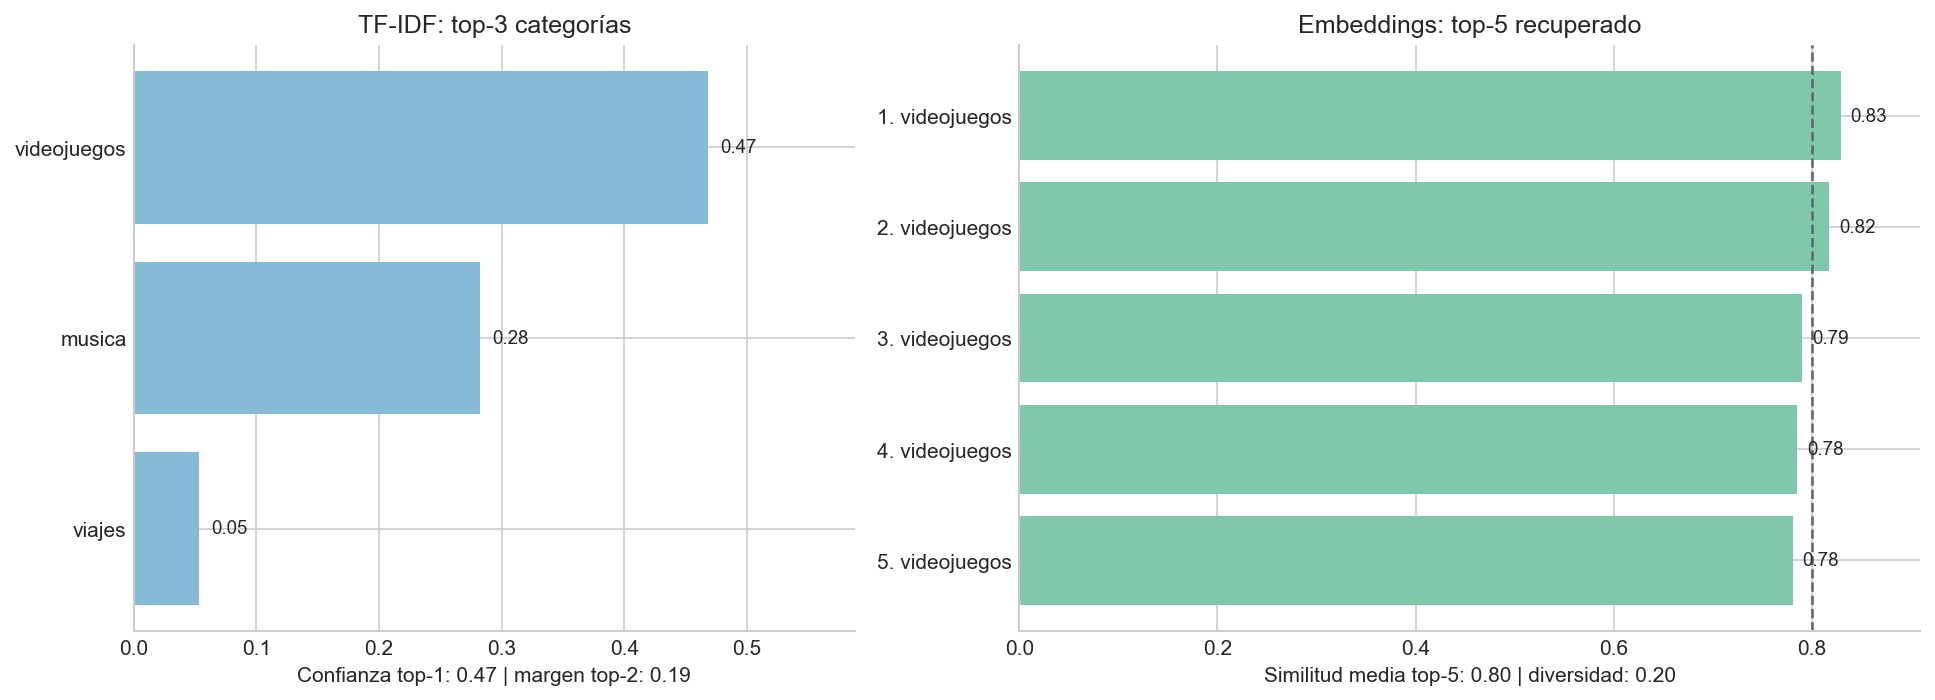

**Lectura rápida:** TF-IDF se queda con la parte más visible del texto y lo resume como videojuegos. Embeddings también acerca la consulta a videojuegos, pero además recupera posts donde juego y música aparecen mezclados, lo que resulta más natural para recomendar contenido parecido.

### Consulta: `viaje en coche por la costa`

**TF-IDF.** Predicción principal: `coches` con score `0.40`. Incertidumbre normalizada: `0.63`. Margen frente a la segunda categoría: `0.03`.

,categoria,probabilidad
0,coches,0.40
1,viajes,0.37
2,playa,0.15


**Embeddings.** Ranking recuperado: `viajes -> coches -> viajes -> coches -> playa`. Similitud media del top-5: `0.82`. Cobertura de categorías esperadas: `1.00`. Diversidad del ranking: `0.60`.

,posicion,categoria,similitud_coseno,relevancia,descripcion,hashtags
0,1,viajes,0.84,alineado,me desperte pensando en esto: viaje en coche por la...,#Escapada
1,2,coches,0.82,alineado,mini update: viaje en coche por la costa asi si,#Destino
2,3,viajes,0.82,alineado,"despues de mil vueltas, caminata eterna por el...",#Mar #Verano #Travel #RoadTrip
3,4,coches,0.80,alineado,plan improvisado: viaje en coche por la costa top!!!,#Travel #Drive #Chill
4,5,playa,0.79,alineado,paseo por la costa en...,nan


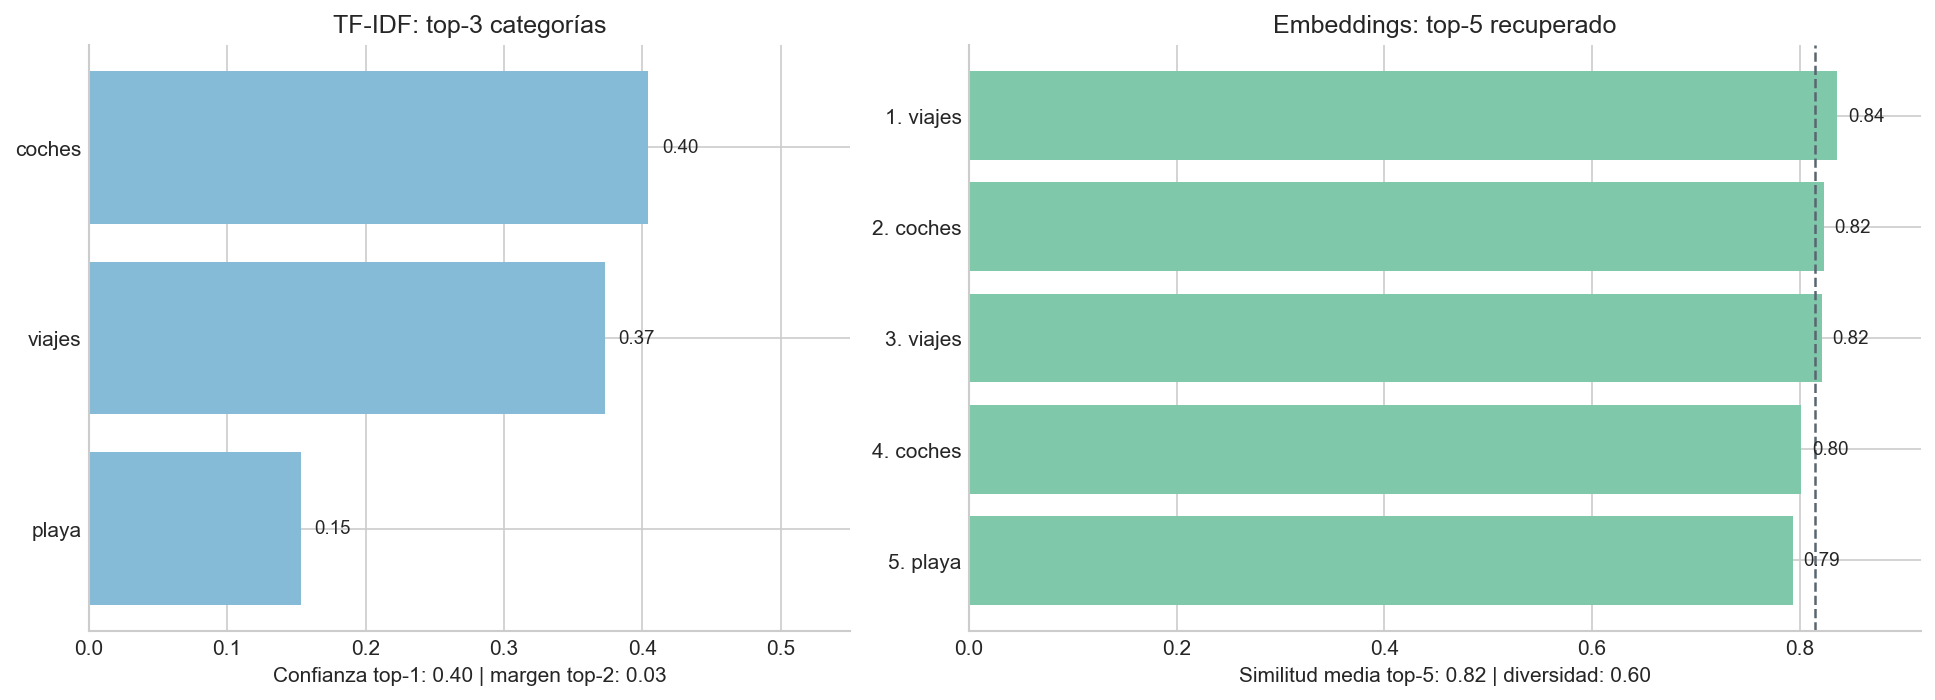

**Lectura rápida:** Aquí la frase mezcla viaje, coche y costa. TF-IDF termina eligiendo una sola categoría, mientras que embeddings devuelve ejemplos repartidos entre viajes, coches y playa. Esa mezcla encaja mejor con la idea de una recomendación real.

### Consulta: `vacaciones con música y playa`

**TF-IDF.** Predicción principal: `playa` con score `0.73`. Incertidumbre normalizada: `0.43`. Margen frente a la segunda categoría: `0.55`.

,categoria,probabilidad
0,playa,0.73
1,viajes,0.18
2,animales,0.02


**Embeddings.** Ranking recuperado: `viajes -> playa -> viajes -> viajes -> playa`. Similitud media del top-5: `0.85`. Cobertura de categorías esperadas: `0.67`. Diversidad del ranking: `0.40`.

,posicion,categoria,similitud_coseno,relevancia,descripcion,hashtags
0,1,viajes,0.87,alineado,"vibe de hoy: vacaciones con musica, playa y maleta...",#Oferta
1,2,playa,0.85,alineado,literalmente vacaciones con musica bro esto esta...,#viajes #travel #mar #verano
2,3,viajes,0.85,alineado,"plan improvisado: vacaciones con musica, playa y...",#Travel #Mood
3,4,viajes,0.83,alineado,"vacaciones con musica, playa y maleta medio rota en...",#Viajes
4,5,playa,0.83,alineado,"literalmente vacaciones con musica, playa y maleta...",#sol #verano


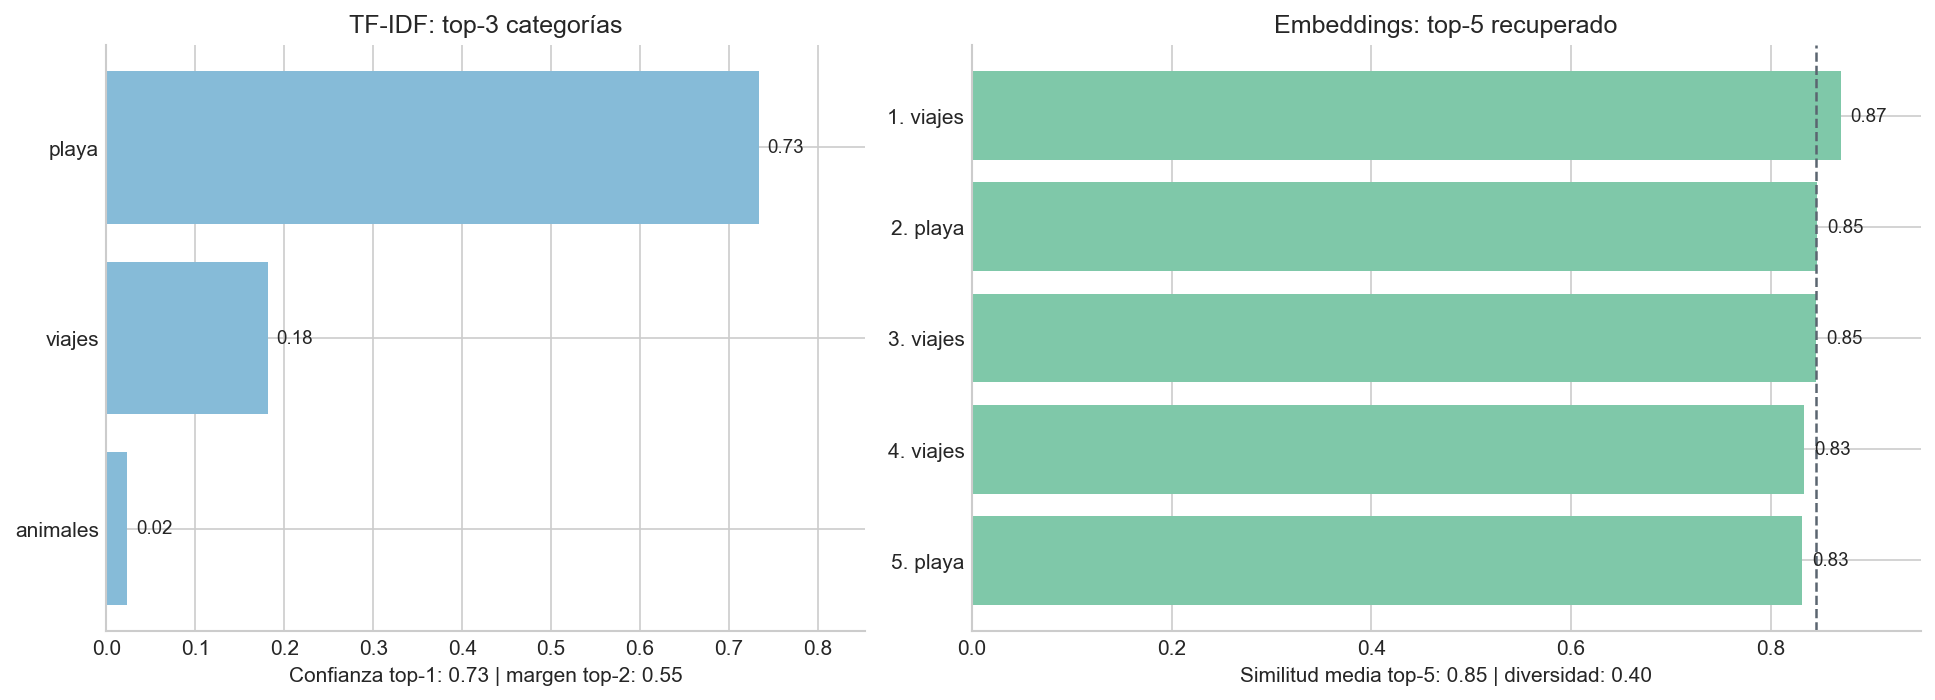

**Lectura rápida:** TF-IDF ofrece una salida simple y limpia: playa. Embeddings aporta una lista más variada y cercana al significado completo del texto, aunque también deja ver algo de ruido en el ranking, algo normal cuando varias señales aparecen juntas.

### Consulta: `nueva canción de Anuel`

**TF-IDF.** Predicción principal: `musica` con score `0.60`. Incertidumbre normalizada: `0.69`. Margen frente a la segunda categoría: `0.51`.

,categoria,probabilidad
0,musica,0.60
1,deporte,0.09
2,viajes,0.08


**Embeddings.** Ranking recuperado: `musica -> viajes -> musica -> musica -> musica`. Similitud media del top-5: `0.72`. Cobertura de categorías esperadas: `1.00`. Diversidad del ranking: `0.40`.

,posicion,categoria,similitud_coseno,relevancia,descripcion,hashtags
0,1,musica,0.74,alineado,JAJA Anuel aparecio en el plan: cancion triste para...,#hoy #live
1,2,viajes,0.73,periférico,mini update: perdido por Ourense siguiendo una...,#musica#temazo
2,3,musica,0.71,alineado,me desperte pensando en esto: perdido por Cantabria...,#Travel #Temazo #Concierto
3,4,musica,0.71,alineado,"Anuel y playlist, no pido mas modo chill 🎸",#Musica
4,5,musica,0.70,alineado,anuel: cancion triste para un plan feliz y ns q...,#Musica


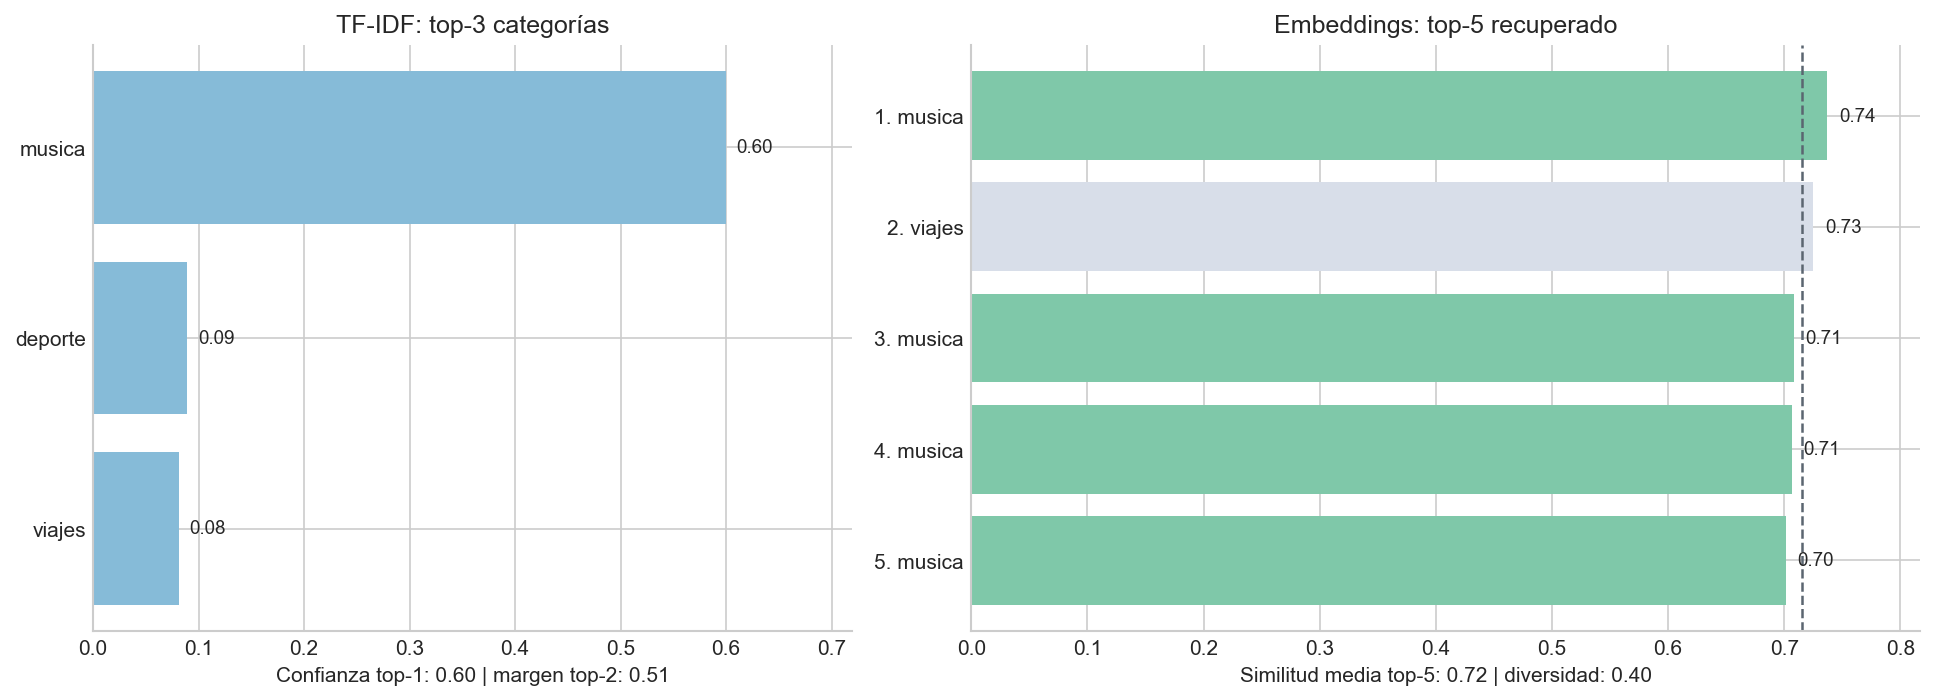

**Lectura rápida:** Este caso es bastante claro y ambos enfoques responden bien. Sirve para recordar que TF-IDF sigue siendo útil cuando el texto es directo y usa palabras muy reconocibles dentro del dominio.

### Consulta: `cocinando mientras veo fútbol`

**TF-IDF.** Predicción principal: `videojuegos` con score `0.24`. Incertidumbre normalizada: `0.92`. Margen frente a la segunda categoría: `0.02`.

,categoria,probabilidad
0,videojuegos,0.24
1,musica,0.23
2,deporte,0.18


**Embeddings.** Ranking recuperado: `cocina -> deporte -> deporte -> deporte -> deporte`. Similitud media del top-5: `0.67`. Cobertura de categorías esperadas: `1.00`. Diversidad del ranking: `0.40`.

,posicion,categoria,similitud_coseno,relevancia,descripcion,hashtags
0,1,cocina,0.75,alineado,me renta literalmente...,#futbol #hoy #cocina
1,2,deporte,0.67,alineado,vibe de hoy: comida sencilla despues del gimnasio...,#Futbol #Entreno
2,3,deporte,0.65,alineado,nadie me preparo para partido del nike y cena...,#Foodie #Running #Futbol
3,4,deporte,0.64,alineado,mini update: comida sencilla despues del gimnasio...,#Top #Futbol
4,5,deporte,0.63,alineado,vibe de hoy: partido del Adidas y cena...,#futbol #partido #cocina


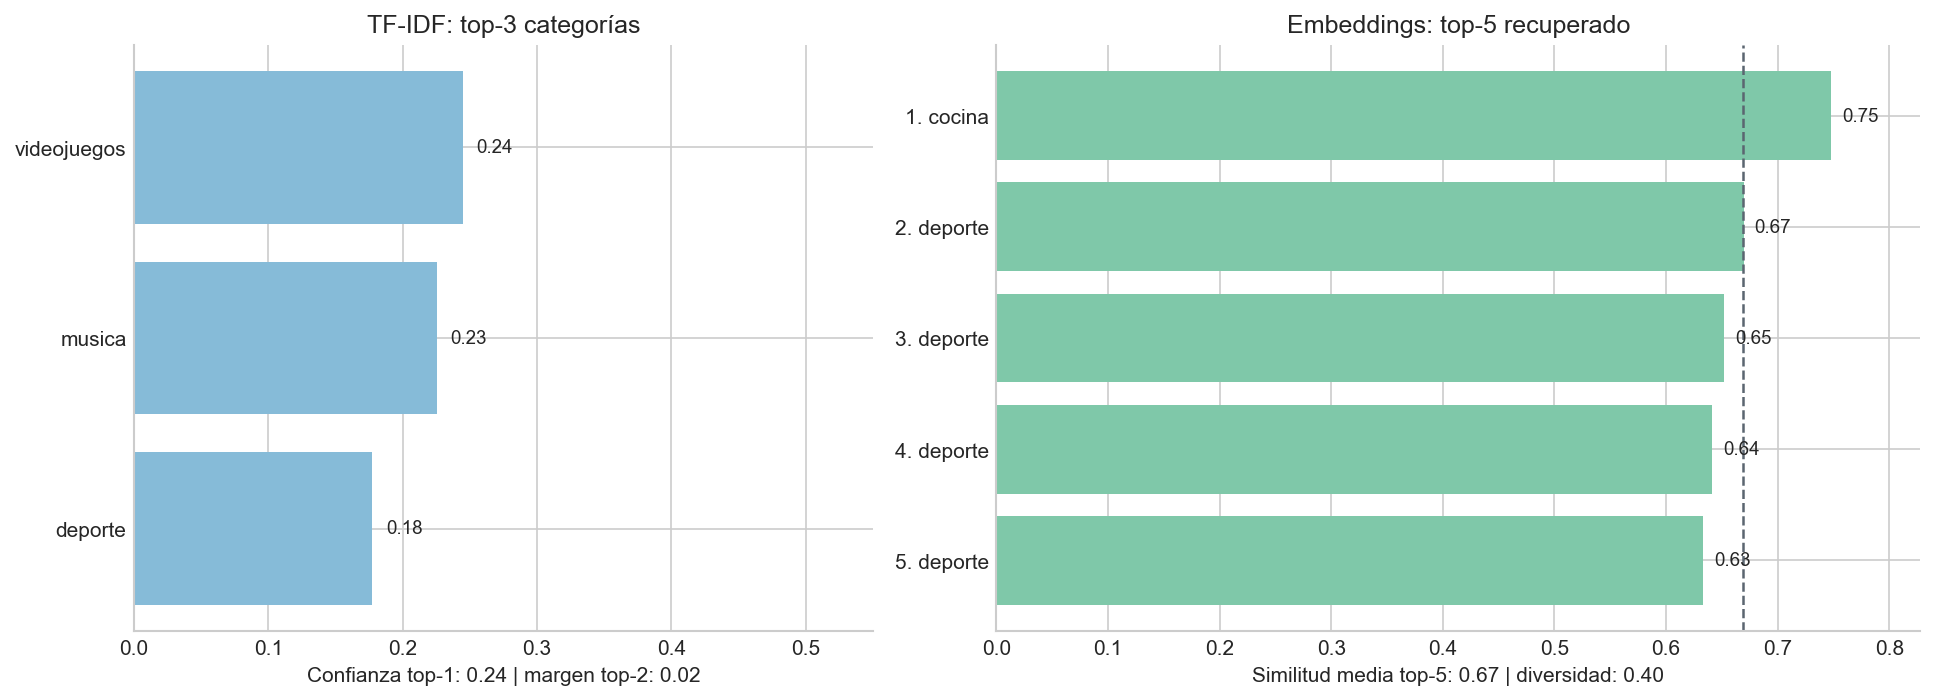

**Lectura rápida:** Este es el ejemplo más ilustrativo. TF-IDF se descoloca y predice una categoría poco intuitiva, mientras que embeddings recupera posts entre cocina y deporte. La lectura práctica es que embeddings maneja mejor los textos ambiguos o mezclados.

In [25]:
for consulta in CONSULTAS:
    mostrar_detalle_consulta(consulta)


## 3. Resumen visual del comportamiento

Después de revisar los ejemplos uno a uno, conviene resumir lo que ocurre sobre una batería más amplia de consultas. La idea no es volver al acierto binario, sino observar señales más útiles:

- qué confianza muestra `TF-IDF` en su primera opción,
- cuánta incertidumbre deja ver cuando la frase es ambigua,
- qué intensidad semántica logra embeddings en el top-5,
- y hasta qué punto ese ranking combina cobertura y diversidad.

Con este enfoque la comparativa se parece más a una observación práctica del sistema y menos a una tabla rígida de aciertos y errores.


In [26]:
filas_resumen = []

for consulta in CONSULTAS_GRAFICA:
    esperado = CATEGORIAS_ESPERADAS[consulta]
    resultado_tfidf = predecir_tfidf(consulta, top_n=3)
    ranking_embeddings = recomendar_embeddings(consulta, top_k=5)
    resumen_embeddings = resumir_embeddings(ranking_embeddings, esperado)
    top_tfidf = resultado_tfidf["top_categorias"]["categoria"].tolist()

    filas_resumen.append(
        {
            "consulta": consulta,
            "tipo_consulta": "base" if consulta in CONSULTAS else "ambigua",
            "categorias_esperadas": ", ".join(sorted(esperado)),
            "tfidf_prediccion": resultado_tfidf["prediccion"],
            "tfidf_confianza_top1": round(resultado_tfidf["confianza_top1"], 4),
            "tfidf_incertidumbre": round(resultado_tfidf["incertidumbre"], 4),
            "tfidf_margen_top2": round(resultado_tfidf["margen_top2"], 4),
            "tfidf_top3": " -> ".join(top_tfidf),
            "embeddings_similitud_top1": round(resumen_embeddings["similitud_top1"], 4),
            "embeddings_similitud_media_top5": round(resumen_embeddings["similitud_media_top5"], 4),
            "embeddings_diversidad_top5": round(resumen_embeddings["diversidad_top5"], 4),
            "embeddings_cobertura_esperada": round(resumen_embeddings["cobertura_esperada"], 4),
            "embeddings_relevantes_top5": round(resumen_embeddings["proporcion_relevantes"], 4),
            "embeddings_categorias_top5": " -> ".join(resumen_embeddings["categorias_recuperadas"]),
        }
    )

df_resumen_ejemplos = pd.DataFrame(filas_resumen)
tabla_resumen = df_resumen_ejemplos[
    [
        "consulta",
        "tipo_consulta",
        "tfidf_prediccion",
        "tfidf_confianza_top1",
        "tfidf_incertidumbre",
        "tfidf_margen_top2",
        "embeddings_similitud_media_top5",
        "embeddings_cobertura_esperada",
        "embeddings_diversidad_top5",
    ]
]
display(
    tabla_resumen.style.format(
        {
            "tfidf_confianza_top1": "{:.2f}",
            "tfidf_incertidumbre": "{:.2f}",
            "tfidf_margen_top2": "{:.2f}",
            "embeddings_similitud_media_top5": "{:.2f}",
            "embeddings_cobertura_esperada": "{:.2f}",
            "embeddings_diversidad_top5": "{:.2f}",
        }
    )
    .background_gradient(subset=["tfidf_confianza_top1", "tfidf_margen_top2"], cmap="Blues")
    .background_gradient(subset=["tfidf_incertidumbre"], cmap="Oranges")
    .background_gradient(
        subset=["embeddings_similitud_media_top5", "embeddings_cobertura_esperada", "embeddings_diversidad_top5"],
        cmap="BuGn",
    )
)


,consulta,tipo_consulta,tfidf_prediccion,tfidf_confianza_top1,tfidf_incertidumbre,tfidf_margen_top2,embeddings_similitud_media_top5,embeddings_cobertura_esperada,embeddings_diversidad_top5
0,jugando al FIFA escuchando música,base,videojuegos,0.47,0.72,0.19,0.80,0.50,0.20
1,viaje en coche por la costa,base,coches,0.40,0.63,0.03,0.82,1.00,0.60
2,vacaciones con música y playa,base,playa,0.73,0.43,0.55,0.85,0.67,0.40
3,nueva canción de Anuel,base,musica,0.60,0.69,0.51,0.72,1.00,0.40
4,cocinando mientras veo fútbol,base,videojuegos,0.24,0.92,0.02,0.67,1.00,0.40
5,playlist para conducir de noche hacia la playa,ambigua,musica,0.61,0.64,0.45,0.72,0.50,0.40
6,sartén en marcha y el partido de fondo,ambigua,deporte,0.56,0.69,0.39,0.73,0.50,0.20
7,escapada improvisada con ventanilla bajada y canciones de verano,ambigua,viajes,0.48,0.74,0.27,0.73,0.67,0.60
8,tarde de consola con cascos y temazos,ambigua,playa,0.71,0.54,0.64,0.59,0.00,0.40
9,"maleta, costa y radio a todo volumen",ambigua,playa,0.44,0.75,0.16,0.57,0.67,0.60


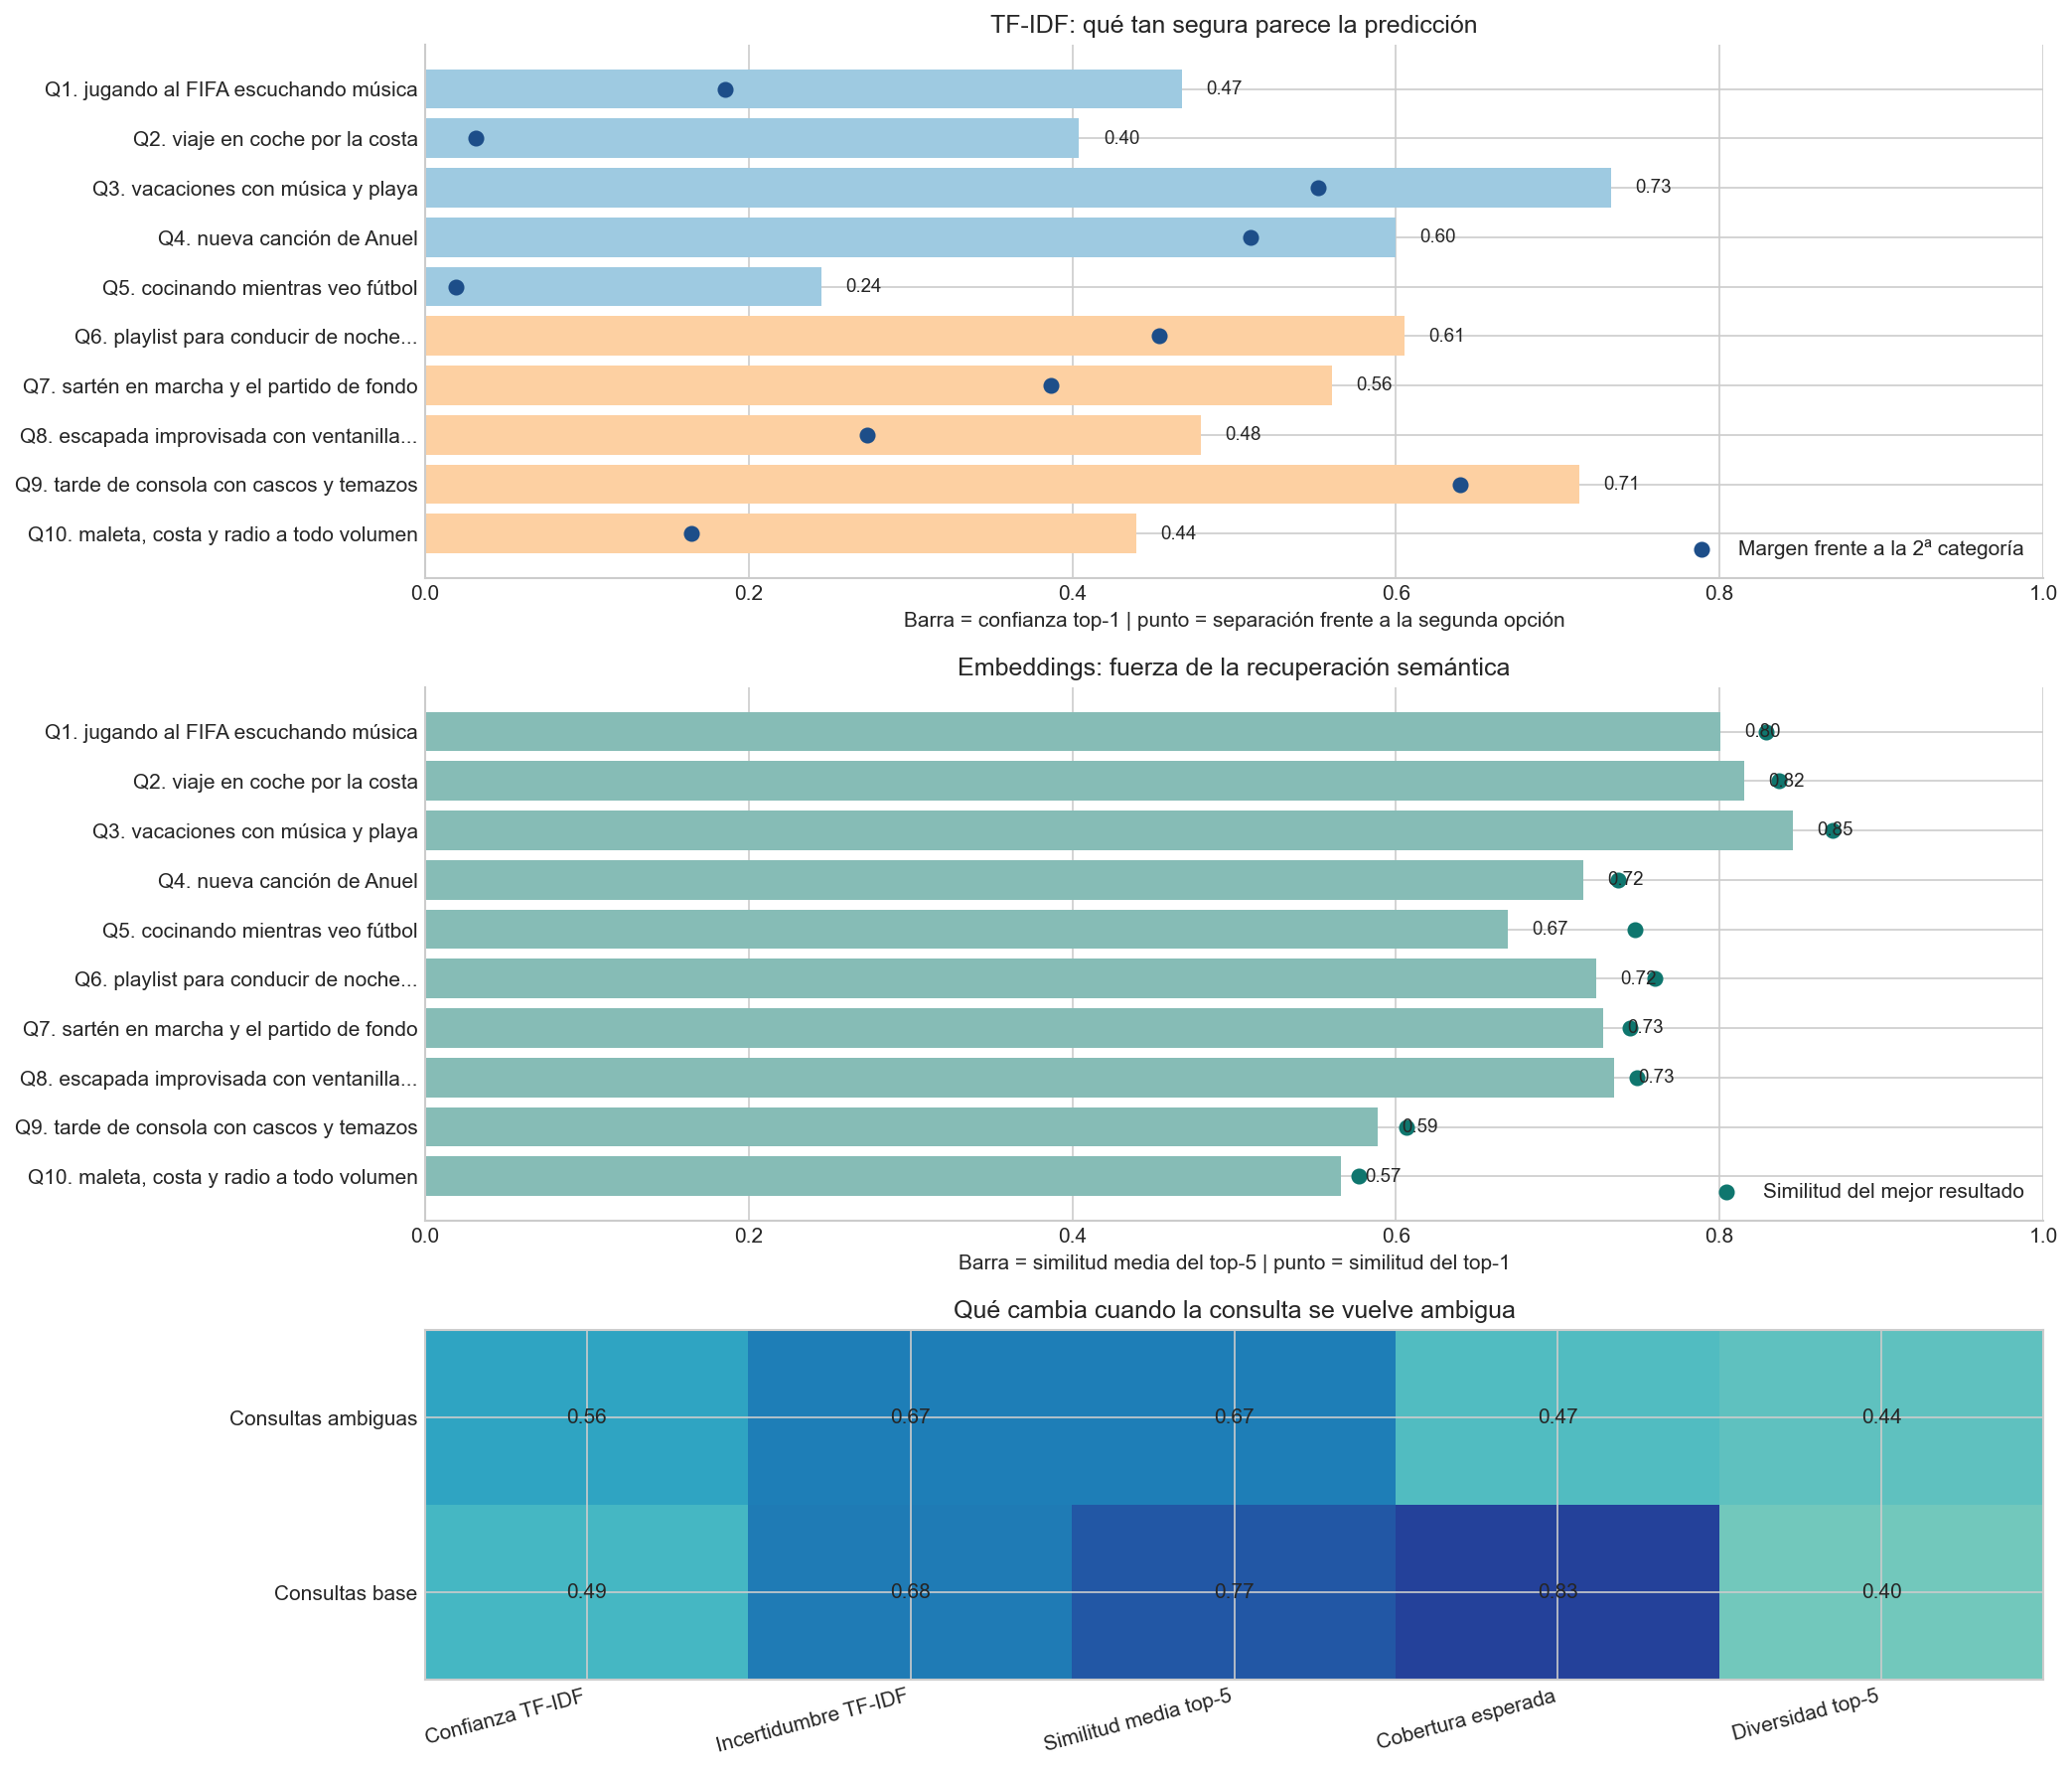

In [27]:
etiquetas_consulta = [
    f"Q{i+1}. {shorten(consulta, width=38, placeholder='...')}"
    for i, consulta in enumerate(df_resumen_ejemplos["consulta"])
]
colores_tipo = [
    "#9ECAE1" if tipo == "base" else "#FDD0A2"
    for tipo in df_resumen_ejemplos["tipo_consulta"]
]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [1.45, 1.45, 0.95]})

axes[0].barh(etiquetas_consulta[::-1], df_resumen_ejemplos["tfidf_confianza_top1"][::-1], color=colores_tipo[::-1])
axes[0].scatter(
    df_resumen_ejemplos["tfidf_margen_top2"][::-1],
    etiquetas_consulta[::-1],
    color="#1D4E89",
    s=45,
    zorder=3,
    label="Margen frente a la 2ª categoría",
)
axes[0].set_xlim(0, 1)
axes[0].set_title("TF-IDF: qué tan segura parece la predicción")
axes[0].set_xlabel("Barra = confianza top-1 | punto = separación frente a la segunda opción")
axes[0].legend(loc="lower right")
for etiqueta, valor in zip(etiquetas_consulta[::-1], df_resumen_ejemplos["tfidf_confianza_top1"][::-1]):
    axes[0].text(valor + 0.015, etiqueta, f"{valor:.2f}", va="center", fontsize=9)

axes[1].barh(etiquetas_consulta[::-1], df_resumen_ejemplos["embeddings_similitud_media_top5"][::-1], color="#86BCB6")
axes[1].scatter(
    df_resumen_ejemplos["embeddings_similitud_top1"][::-1],
    etiquetas_consulta[::-1],
    color="#0F766E",
    s=45,
    zorder=3,
    label="Similitud del mejor resultado",
)
axes[1].set_xlim(0, 1)
axes[1].set_title("Embeddings: fuerza de la recuperación semántica")
axes[1].set_xlabel("Barra = similitud media del top-5 | punto = similitud del top-1")
axes[1].legend(loc="lower right")
for etiqueta, valor in zip(etiquetas_consulta[::-1], df_resumen_ejemplos["embeddings_similitud_media_top5"][::-1]):
    axes[1].text(valor + 0.015, etiqueta, f"{valor:.2f}", va="center", fontsize=9)

resumen_por_tipo = (
    df_resumen_ejemplos.groupby("tipo_consulta")
    [[
        "tfidf_confianza_top1",
        "tfidf_incertidumbre",
        "embeddings_similitud_media_top5",
        "embeddings_cobertura_esperada",
        "embeddings_diversidad_top5",
    ]]
    .mean()
    .rename(
        index={"base": "Consultas base", "ambigua": "Consultas ambiguas"},
        columns={
            "tfidf_confianza_top1": "Confianza TF-IDF",
            "tfidf_incertidumbre": "Incertidumbre TF-IDF",
            "embeddings_similitud_media_top5": "Similitud media top-5",
            "embeddings_cobertura_esperada": "Cobertura esperada",
            "embeddings_diversidad_top5": "Diversidad top-5",
        },
    )
)
matriz = resumen_por_tipo.to_numpy()
axes[2].imshow(matriz, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)
axes[2].set_title("Qué cambia cuando la consulta se vuelve ambigua")
axes[2].set_xticks(np.arange(resumen_por_tipo.shape[1]))
axes[2].set_xticklabels(resumen_por_tipo.columns, rotation=15, ha="right")
axes[2].set_yticks(np.arange(resumen_por_tipo.shape[0]))
axes[2].set_yticklabels(resumen_por_tipo.index)
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        axes[2].text(j, i, f"{matriz[i, j]:.2f}", ha="center", va="center", fontsize=10)

for ax in axes[:2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
GRAFICA_COMPARACION_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(GRAFICA_COMPARACION_PATH, dpi=150, bbox_inches="tight")
display(Image(filename=str(GRAFICA_COMPARACION_PATH)))
plt.close(fig)


Estas visualizaciones ya no preguntan simplemente si el modelo acierta o falla. Lo que intentan mostrar es algo más útil para interpretar el sistema: si `TF-IDF` decide con claridad o con dudas, si embeddings recupera una señal semántica estable y qué cambia cuando la consulta deja de ser directa y empieza a mezclar varias intenciones.


## 4. Observaciones simples

- En consultas directas, `TF-IDF` suele concentrar más probabilidad en una sola categoría y el margen con la segunda opción tiende a ser más claro.
- Cuando la frase mezcla señales de varias categorías, la confianza de `TF-IDF` puede seguir siendo alta, pero su incertidumbre y su margen dejan ver que la decisión ya no es tan limpia.
- Embeddings no entrega una etiqueta cerrada, sino un vecindario semántico. Por eso resulta más natural leer sus resultados como ranking que como acierto puntual.
- La similitud media del top-5 ayuda a ver si la recuperación mantiene coherencia global, mientras que la diversidad indica si el ranking abre varias facetas útiles del mismo significado.
- En recomendación práctica, esa combinación entre cobertura, similitud y diversidad suele ser más informativa que una barra binaria de acierto.


## 5. Comparativa sencilla final

La idea no es convertir esto en una tabla de métricas, sino resumir cómo se ha comportado cada enfoque dentro del proyecto.


In [28]:
comparativa_final = pd.DataFrame(
    [
        ["Qué devuelve", "Etiqueta con score", "Ranking con similitudes"],
        ["Señal más útil", "Confianza y margen", "Cobertura y diversidad"],
        ["Cuando destaca", "Consultas directas", "Consultas ambiguas o mezcladas"],
        ["Dependencia del vocabulario", "Alta", "Baja"],
        ["Tipo de relación", "Coincidencia léxica", "Cercanía semántica"],
        ["Adecuación para recomendación", "Correcta como baseline", "Más natural para uso real"],
    ],
    columns=["Aspecto", "TF-IDF", "Embeddings"],
)

display(comparativa_final)


,Aspecto,TF-IDF,Embeddings
0,Qué devuelve,Etiqueta con score,Ranking con similitudes
1,Señal más útil,Confianza y margen,Cobertura y diversidad
2,Cuando destaca,Consultas directas,Consultas ambiguas o mezcladas
3,Dependencia del vocabulario,Alta,Baja
4,Tipo de relación,Coincidencia léxica,Cercanía semántica
5,Adecuación para recomendación,Correcta como baseline,Más natural para uso real


## 6. Conclusión

La comparación deja una idea bastante clara. `TF-IDF` fue un buen primer paso para el proyecto: es rápido, sencillo y responde bien cuando el texto es corto y la intención está muy marcada. Como baseline, cumple su función y ayuda a entender el problema.

Aun así, cuando el objetivo pasa de clasificar a recomendar contenido parecido, embeddings encaja mejor. Maneja mejor la ambigüedad, conecta textos por significado y produce resultados más naturales para un sistema de recomendación. Por eso, dentro de la evolución del proyecto, el salto de TF-IDF a embeddings no se entiende como una ruptura, sino como un paso lógico hacia un sistema más flexible y más cercano al comportamiento real de los usuarios.
